# Employee Attrition Prediction using Decision Tree and Random Forest Classification

**Name:** Akshat Garg  

**Registration Number:** 23BCE10641

**Application Number:** IN26011052

**Batch Number:** 1A

**Email ID:** akshat.23bce10641@vitbhopal.ac.in 

In [1]:
import os
import getpass
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [2]:
!pip install -q kaggle

os.environ['KAGGLE_USERNAME'] = input("Kaggle Username: ")
os.environ['KAGGLE_KEY'] = getpass.getpass("Kaggle API Key: ")

from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()
api.dataset_download_files('pavansubhasht/ibm-hr-analytics-attrition-dataset', path='.', unzip=True)

df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.head()

Kaggle Username:  AkshatGarg
Kaggle API Key:  ········


Dataset URL: https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
# Identify Target Variable, Categorical Features, and Numerical Features
target_var = 'Attrition'
cat_features = df.select_dtypes(include=['object']).columns.drop(target_var).tolist()
num_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Target Variable:", target_var)
print("\nCategorical Features ( Count:", len(cat_features), "):")
print(cat_features)
print("\nNumerical Features ( Count:", len(num_features), "):")
print(num_features)

print("\n--- Dataset Info ---")
df.info()

print("\n--- Summary Statistics ---")
df.describe()

Target Variable: Attrition

Categorical Features ( Count: 8 ):
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']

Numerical Features ( Count: 26 ):
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1  

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [4]:
# Check for missing values across all columns
print("Total missing values in dataset:", df.isnull().sum().sum())

# Drop non-informative / constant columns
cols_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df_clean = df.drop(columns=cols_to_drop, errors='ignore')

# Encode target variable: Yes -> 1, No -> 0
df_clean['Attrition'] = df_clean['Attrition'].map({'Yes': 1, 'No': 0})

# Encode remaining categorical variables using One-Hot Encoding
df_encoded = pd.get_dummies(df_clean, drop_first=True)

# Separate features and target
X = df_encoded.drop(columns=['Attrition'])
y = df_encoded['Attrition']

# Split dataset into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Total missing values in dataset: 0

X_train shape: (1176, 44)
X_test shape: (294, 44)


In [5]:
# Model 1: Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

# Model 2: Random Forest Classifier (100 estimators)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Decision Tree and Random Forest models trained successfully.")

Decision Tree and Random Forest models trained successfully.


--- Model Performance Comparison ---
   Metric  Decision Tree  Random Forest
 Accuracy       0.765306       0.833333
Precision       0.310345       0.416667
   Recall       0.382979       0.106383
 F1-Score       0.342857       0.169492


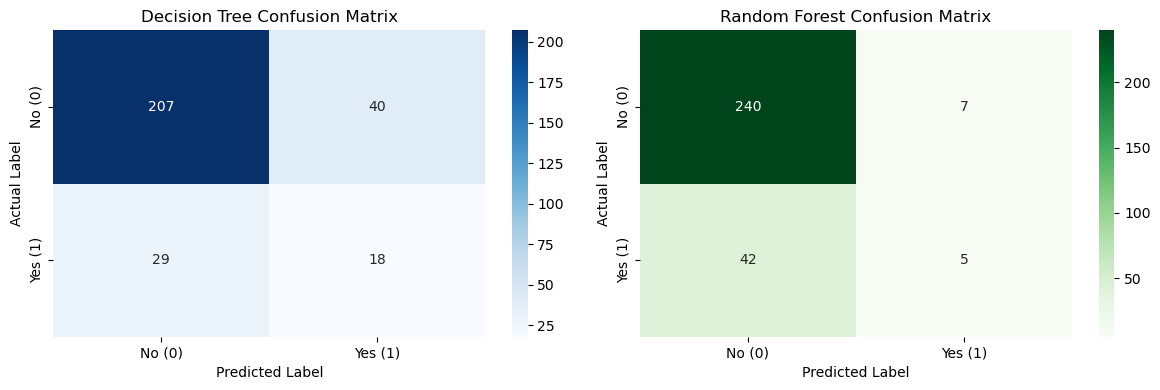

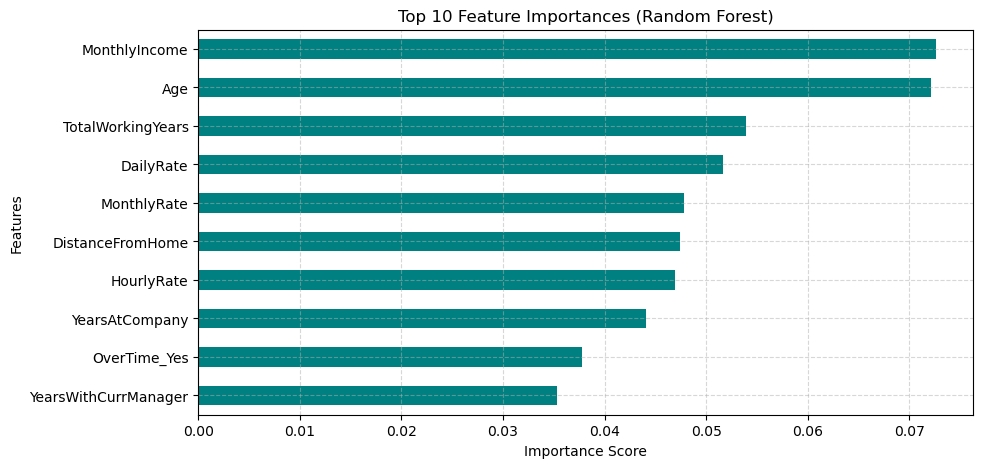

In [6]:
# Task 4: Calculate Metrics for Decision Tree
acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt)
rec_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

# Calculate Metrics for Random Forest
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

# Display Comparison Summary
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Decision Tree': [acc_dt, prec_dt, rec_dt, f1_dt],
    'Random Forest': [acc_rf, prec_rf, rec_rf, f1_rf]
})
print("--- Model Performance Comparison ---")
print(metrics_df.to_string(index=False))

# Confusion Matrices Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No (0)', 'Yes (1)'], yticklabels=['No (0)', 'Yes (1)'])
axes[0].set_title('Decision Tree Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('Actual Label')

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['No (0)', 'Yes (1)'], yticklabels=['No (0)', 'Yes (1)'])
axes[1].set_title('Random Forest Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('Actual Label')

plt.tight_layout()
plt.show()

# Feature Importance Plot for Random Forest
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importances.head(10).plot(kind='barh', color='teal').invert_yaxis()
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [7]:
print("--- Model Observations ---")
print("1. Overall Accuracy: Random Forest achieved higher overall accuracy (83.33%) compared to Decision Tree (76.53%) by significantly reducing False Positives (7 vs 40).")
print("2. Class Imbalance Impact: Standard Random Forest heavily favored the majority class ('No Attrition'), leading to higher Precision (41.67%) but lower Recall (10.64%) compared to Decision Tree (38.30%).")
print("3. Feature Importance: 'MonthlyIncome', 'Age', and 'TotalWorkingYears' emerged as the top three key drivers predicting employee attrition.")

--- Model Observations ---
1. Overall Accuracy: Random Forest achieved higher overall accuracy (83.33%) compared to Decision Tree (76.53%) by significantly reducing False Positives (7 vs 40).
2. Class Imbalance Impact: Standard Random Forest heavily favored the majority class ('No Attrition'), leading to higher Precision (41.67%) but lower Recall (10.64%) compared to Decision Tree (38.30%).
3. Feature Importance: 'MonthlyIncome', 'Age', and 'TotalWorkingYears' emerged as the top three key drivers predicting employee attrition.


## Conclusion

This project evaluated Decision Tree and Random Forest classification models to predict employee attrition using the IBM HR Analytics dataset. Overall, Random Forest demonstrated superior overall accuracy (83.33% vs. 76.53%) and precision (41.67% vs. 31.03%), primarily by reducing false positive predictions. However, due to class imbalance in the target variable, the unweighted Random Forest model suffered from low recall on the minority attrition class (10.64%).

Random Forest generally outperforms single Decision Trees because it uses bootstrap aggregation (bagging) and random feature selection. By averaging the predictions of 100 decorrelated decision trees, it effectively reduces variance and controls overfitting[cite: 2]. 

A major limitation of single Decision Trees is high variance; small changes in training data can lead to drastically different trees and overfitted decision boundaries[cite: 2]. Conversely, a key limitation of Random Forest is its lack of interpretability—it operates as a "black box" model where individual decision paths cannot be easily visually inspected or audited[cite: 2].